In [1]:
!pip install "unstructured[all-docs]" langchain langchain-community langchain-openai langchain-core chromadb nltk


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import nltk
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/unsloth/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/unsloth/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
import sys
# conda 환경이면 conda-forge가 가장 안전 (root/apt 불필요)
!conda install -y -q -c conda-forge tesseract poppler
!which tesseract && tesseract --version
!which pdftoppm   # poppler 확인

Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

# All requested packages already installed.

/opt/conda/bin/tesseract
tesseract 5.5.1
 leptonica-1.83.1
  libgif 5.2.2 : libjpeg 8d (libjpeg-turbo 3.0.0) : libpng 1.6.55 : libtiff 4.7.1 : zlib 1.3.1 : libwebp 1.6.0 : libopenjp2 2.5.4
 Found AVX2
 Found AVX
 Found FMA
 Found SSE4.1
 Found OpenMP 201511
 Found libarchive 3.7.7 zlib/1.3.1 liblzma/5.8.1 bz2lib/1.0.8 liblz4/1.10.0 libzstd/1.5.7
/opt/conda/bin/pdftoppm


In [4]:
!tesseract --list-langs

List of available languages in "/opt/conda/share/tessdata/" (125):
afr
amh
ara
asm
aze
aze_cyrl
bel
ben
bod
bos
bre
bul
cat
ceb
ces
chi_sim
chi_sim_vert
chi_tra
chi_tra_vert
chr
cos
cym
dan
deu
div
dzo
ell
eng
enm
epo
equ
est
eus
fao
fas
fil
fin
fra
frk
frm
fry
gla
gle
glg
grc
guj
hat
heb
hin
hrv
hun
hye
iku
ind
isl
ita
ita_old
jav
jpn
jpn_vert
kan
kat
kat_old
kaz
khm
kir
kmr
kor
kor_vert
lao
lat
lav
lit
ltz
mal
mar
mkd
mlt
mon
mri
msa
mya
nep
nld
nor
oci
ori
osd
pan
pol
por
pus
que
ron
rus
san
sin
slk
slv
snd
spa
spa_old
sqi
srp
srp_latn
sun
swa
swe
syr
tam
tat
tel
tgk
tha
tir
ton
tur
uig
ukr
urd
uzb
uzb_cyrl
vie
yid
yor


## 0. 환경 설정

In [5]:
import os
import uuid
import base64
import re

# --- LM Studio ---
LMSTUDIO_BASE_URL = "http://host.docker.internal:12345/v1"  # /v1 까지 포함
LMSTUDIO_API_KEY  = "lm-studio"                              # LM Studio는 키 검증 안 함 (더미)

EMBED_MODEL = "embedding-8b:sl"
LLM_MODEL   = "gemma4-e2b:tr"

# --- Chroma 서버 ---
CHROMA_HOST = "chromadb"
CHROMA_PORT = 8000

# --- 입력 파일 (노트북과 같은 경로) ---
FPATH = "."
FNAME = "practice3.pdf"


def strip_think(text: str) -> str:
    """qwen3 등 추론 모델의 <think>...</think> 블록 제거."""
    if text is None:
        return ""
    return re.sub(r"(^|<think>).*?</think>", "", text, flags=re.DOTALL).strip()

In [6]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# 채팅 / 비전(멀티모달) 모델
llm = ChatOpenAI(
    model=LLM_MODEL,
    base_url=LMSTUDIO_BASE_URL,
    api_key=LMSTUDIO_API_KEY,
    temperature=0,
    max_tokens=1024,
    # qwen3 사고 모드를 끄려면 아래 주석 해제 (LM Studio 버전에 따라 무시될 수 있음)
    # extra_body={"chat_template_kwargs": {"enable_thinking": False}},
)

# 임베딩 모델
# check_embedding_ctx_length=False : tiktoken 토큰 배열 대신 원문 문자열을 전송 → LM Studio 호환
embeddings = OpenAIEmbeddings(
    model=EMBED_MODEL,
    base_url=LMSTUDIO_BASE_URL,
    api_key=LMSTUDIO_API_KEY,
    check_embedding_ctx_length=False,
)

# --- 연결 확인 ---
print("LLM  :", strip_think(llm.invoke("연결 테스트. 'ok' 라고만 답하세요.").content)[:50])
print("EMBED:", len(embeddings.embed_query("연결 테스트")), "차원")

LLM  : ok
EMBED: 4096 차원


## 1. 데이터 전처리 — PDF 요소 추출

`partition_pdf` 로 텍스트/표/이미지를 한 번에 추출합니다. `extract_image_block_output_dir=FPATH` 로 이미지가 현재 경로에 `.jpg` 로 저장됩니다.

In [7]:
import os, pickle
from unstructured.partition.pdf import partition_pdf

IMG_DIR = "practice3"
os.makedirs(IMG_DIR, exist_ok=True)
CACHE = os.path.join(IMG_DIR, "raw_pdf_elements.pkl")

if os.path.exists(CACHE):
    with open(CACHE, "rb") as f:
        raw_pdf_elements = pickle.load(f)
    print("캐시 로드:", len(raw_pdf_elements))
else:
    raw_pdf_elements = partition_pdf(
        filename=os.path.join(FPATH, FNAME),
        extract_images_in_pdf=True,
        infer_table_structure=True,
        chunking_strategy="by_title",
        extract_image_block_output_dir=IMG_DIR,
        languages=["kor", "eng"],     # 한글 OCR
    )
    with open(CACHE, "wb") as f:
        pickle.dump(raw_pdf_elements, f)
    print("추출+저장:", len(raw_pdf_elements))

print("총 요소 수:", len(raw_pdf_elements))

캐시 로드: 45
총 요소 수: 45


In [8]:
# 표 / 텍스트 분리
tables = []
texts = []
for element in raw_pdf_elements:
    t = str(type(element))
    if "unstructured.documents.elements.Table" in t:
        tables.append(str(element))
    elif "unstructured.documents.elements.CompositeElement" in t:
        texts.append(str(element))

print("tables:", len(tables), "/ texts:", len(texts))

tables: 10 / texts: 35


## 2. 텍스트 · 표 요약

원본을 그대로 임베딩하지 않고, 검색에 최적화된 요약을 생성해 임베딩합니다.

In [9]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

prompt_text = """당신은 표와 텍스트를 요약하여 검색할 수 있도록 돕는 어시스턴트입니다.
이 요약은 임베딩되어 원본 텍스트나 표 요소를 검색하는 데 사용될 것입니다.
표 또는 텍스트에 대한 간결한 요약을 제공하여 검색에 최적화된 형태로 만들어 주세요.
표 또는 텍스트: {element}"""

prompt = ChatPromptTemplate.from_template(prompt_text)

# 요약 체인: 입력 element → 프롬프트 → LLM → 문자열 → <think> 제거
summarize_chain = (
    {"element": lambda x: x}
    | prompt
    | llm
    | StrOutputParser()
    | (lambda s: strip_think(s))
)

text_summaries = summarize_chain.batch(texts, {"max_concurrency": 20}) if texts else []
table_summaries = summarize_chain.batch(tables, {"max_concurrency": 20}) if tables else []

print("표 요약 예시:\n", table_summaries[0] if table_summaries else "(표 없음)")
print("\n텍스트 요약 예시:\n", text_summaries[0] if text_summaries else "(텍스트 없음)")

표 요약 예시:
 제공하신 데이터를 검색에 최적화된 형태로 요약했습니다. 이 요약은 시간(연도/주)과 분류(전체, 국내발생, 해외유입)를 기준으로 주요 수치를 정리한 것입니다.

---

### 📊 데이터 요약 (검색 최적화)

**분석 대상:** 연도별 및 기간별 데이터 (2020년, 2023년, 2024년, 42주 등)의 총합, 국내 발생, 해외 유입 수치.

**핵심 분류 항목:**
1. **전체 (Total):** [관련 수치]
2. **국내발생 (Domestic Origin):** [관련 수치]
3. **해외유입 (Foreign Inflow):** [관련 수치]

**주요 데이터 포인트:**

*   **연도별/기간별 값:** 2020년, 2023년, 2024년, 42주 관련 데이터 포함.
*   **전체 합계:** 385
*   **국내 발생 수치:** 356, 630, 673, 382, 274, 20, 38, 29
*   **해외 유입 수치:** 74, 35

---

**💡 검색 키워드 추천:**
`2020년 데이터`, `2024년 수치`, `국내발생`, `해외유입`, `전체 합계`, `42주`

텍스트 요약 예시:
 **요약:**

42주차(10.13.~10.19.) 데이터로, 주차별 국내 발생, 해외 유입, 전체 현황을 비교하는 통계 표 구조입니다.


## 3. 이미지 요약 (base64)

LM Studio 멀티모달 모델에 **base64 data URL** 로 이미지를 전달해 요약을 생성합니다.

In [10]:
def encode_image(image_path: str) -> str:
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

# 추출된 이미지 파일을 base64 로 인코딩
img_base64_list = []
for img_file in sorted(os.listdir(IMG_DIR)):
    if img_file.lower().endswith((".jpg", ".jpeg", ".png")):
        img_base64_list.append(encode_image(os.path.join(IMG_DIR, img_file)))

print("이미지 수:", len(img_base64_list))

이미지 수: 43


In [11]:
from langchain_core.messages import HumanMessage

IMAGE_PROMPT = """당신은 이미지를 요약하여 검색을 위해 사용할 수 있도록 돕는 어시스턴트입니다.
이 요약은 임베딩되어 원본 이미지를 검색하는 데 사용됩니다.
이미지 검색에 최적화된 간결한 요약을 작성하세요."""

def image_summarize(img_base64: str) -> str:
    msg = llm.invoke([
        HumanMessage(content=[
            {"type": "text", "text": IMAGE_PROMPT},
            {"type": "image_url",
             "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"}},
        ])
    ])
    return strip_think(msg.content)

image_summaries = [image_summarize(b) for b in img_base64_list]
print(image_summaries[0] if image_summaries else "(이미지 없음)")

2024년 말라리아 주간소식지(Weekly Malaria Surveillance Report) 표지. 질병관리청(KDCA)에서 발행한 42주차 보고서(10.13.~10.19.).


## 4. 멀티벡터 검색기 구성 (Chroma 서버 + InMemoryStore)

- `vectorstore` (Chroma 서버): 요약본을 임베딩하여 저장 → 의미 기반 검색용
- `docstore` (InMemoryStore): 원본 텍스트/표/이미지(base64) 저장
- `MultiVectorRetriever`: 요약으로 검색하고 원본을 반환

In [12]:
import chromadb
from langchain_core.stores import InMemoryStore
from langchain_core.documents import Document

# Chroma: langchain_community 는 deprecation 경고만 뜰 뿐 동작함
from langchain_community.vectorstores import Chroma

# MultiVectorRetriever: langchain 1.x 에서 위치 이동 → 폴백 처리
try:
    from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
except ImportError:
    try:
        from langchain.retrievers.multi_vector import MultiVectorRetriever
    except ImportError:
        from langchain.retrievers import MultiVectorRetriever

# Chroma 서버(컨테이너) 접속
chroma_client = chromadb.HttpClient(host=CHROMA_HOST, port=CHROMA_PORT)

vectorstore = Chroma(
    client=chroma_client,
    collection_name="multi_modal_rag",
    embedding_function=embeddings,
)

docstore = InMemoryStore()
id_key = "doc_id"

retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=docstore,
    id_key=id_key,
)
print("retriever 준비 완료:", type(retriever).__name__)

/tmp/ipykernel_1750/3098310733.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma
Skipping import of cpp extensions due to incompatible torch version 2.12.1+cu130 for torchao version 0.14.0         Please see GitHub issue #2919 for more info


retriever 준비 완료: MultiVectorRetriever


/tmp/ipykernel_1750/3098310733.py:20: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


In [13]:
import hashlib
from langchain_core.stores import InMemoryStore


def _ids(prefix, items):
    # 원본 내용 기반 결정적 id → 재실행해도 동일(멱등), 원본이 유니크하므로 id도 유니크
    return [f"{prefix}-{hashlib.sha1(x.encode('utf-8')).hexdigest()[:16]}" for x in items]


# --- 임베딩 엔드포인트 헬스 체크 (죽었으면 바로 알 수 있게) ---
try:
    _dim = len(embeddings.embed_query("healthcheck"))
    print(f"[embed] OK, dim={_dim}")
except Exception as e:
    raise RuntimeError(
        f"임베딩 엔드포인트 응답 없음: {type(e).__name__} - {str(e)[:150]}\n"
        "→ LM Studio에서 embedding 모델 로드 상태/VRAM 확인 후 다시 실행하세요."
    )

# --- 재실행 안전: 기존 컬렉션 내용 제거 ---
_existing = vectorstore.get()
if _existing and _existing.get("ids"):
    vectorstore.delete(ids=_existing["ids"])

# --- docstore 도 새로 (이전 실행 잔여 키 제거) ---
retriever.docstore = InMemoryStore()

# --- 결정적 id (원본 기준) ---
doc_ids   = _ids("text",  texts)
table_ids = _ids("table", tables)
img_ids   = _ids("img",   img_base64_list)

# --- 원본 저장 (docstore, mset 은 같은 키면 덮어씀) ---
if texts:           retriever.docstore.mset(list(zip(doc_ids, texts)))
if tables:          retriever.docstore.mset(list(zip(table_ids, tables)))
if img_base64_list: retriever.docstore.mset(list(zip(img_ids, img_base64_list)))

print(f"docstore 저장 - text:{len(doc_ids)} table:{len(table_ids)} img:{len(img_ids)}")

[embed] OK, dim=4096
docstore 저장 - text:35 table:10 img:43


In [14]:
import time
from langchain_core.documents import Document


def safe_add(summaries, ids, label, batch=4, retries=5):
    # 빈 요약 제외 + id 중복 제거(동일 요약/원본이 겹쳐도 1건만)
    uniq = {}
    for s, i in zip(summaries, ids):
        if s and s.strip():
            uniq[i] = s.strip()
    items = list(uniq.items())                       # [(id, summary), ...]
    if not items:
        print(f"[{label}] 저장할 항목 없음")
        return 0

    added = 0
    for k in range(0, len(items), batch):
        chunk = items[k:k + batch]
        docs = [Document(page_content=s, metadata={id_key: i}) for i, s in chunk]
        vids = [i for i, _ in chunk]
        for attempt in range(retries):
            try:
                vectorstore.add_documents(docs, ids=vids)   # 같은 id면 upsert
                added += len(docs)
                break
            except Exception as e:
                wait = 2 ** attempt
                print(f"[{label}] 배치 {k // batch} 재시도 {attempt + 1}/{retries} "
                      f"({type(e).__name__}) {wait}s 대기 :: {str(e)[:100]}")
                time.sleep(wait)
        else:
            print(f"[{label}] 배치 {k // batch} 최종 실패:", vids)
    return added


n1 = safe_add(text_summaries,  doc_ids,   "text")
n2 = safe_add(table_summaries, table_ids, "table")
n3 = safe_add(image_summaries, img_ids,   "img")
print(f"저장 완료 - text:{n1} table:{n2} img:{n3}")

저장 완료 - text:35 table:10 img:34


## 5. 검색 확인

In [15]:
from base64 import b64decode

QUESTION = "말라리아 군집 사례는 어떤가요?"

docs = retriever.invoke(QUESTION)
print("검색 결과 수:", len(docs))

def split_image_text_types(docs):
    """base64 디코딩 성공 여부로 이미지/텍스트 분리."""
    b64, text = [], []
    for doc in docs:
        try:
            b64decode(doc, validate=True)
            b64.append(doc)
        except Exception:
            text.append(doc)
    return {"images": b64, "texts": text}

docs_by_type = split_image_text_types(docs)
print("images:", len(docs_by_type["images"]), "/ texts:", len(docs_by_type["texts"]))

검색 결과 수: 4
images: 2 / texts: 2



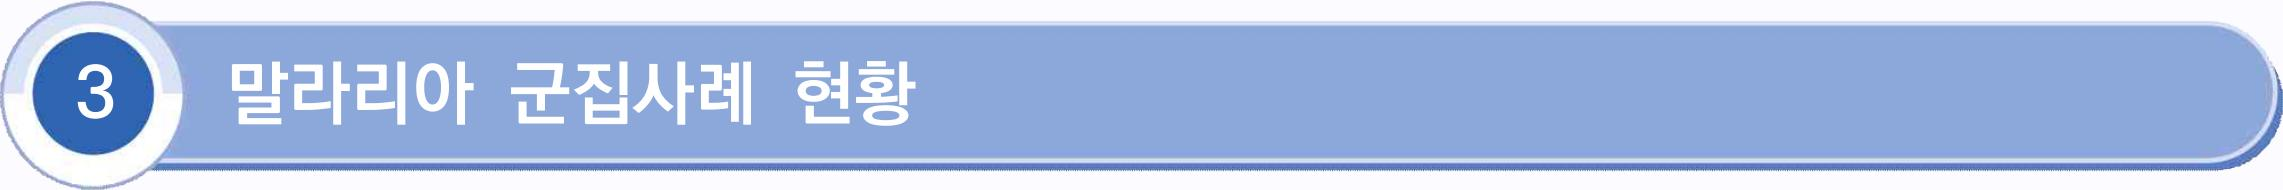

In [16]:
from IPython.display import display, HTML

def plt_img_base64(img_base64):
    display(HTML(f'<img src="data:image/jpeg;base64,{img_base64}" />'))

if docs_by_type["images"]:
    plt_img_base64(docs_by_type["images"][0])
else:
    print("검색된 이미지 없음")

## 6. 답변 생성 (멀티모달 RAG 파이프라인)

검색된 텍스트/표 + 이미지(base64)를 함께 프롬프트로 구성해 답변을 생성합니다.

In [17]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

def prompt_func(data):
    format_texts = "\n".join(data["context"]["texts"])
    text = f"""다음 문맥에만 기반하여 질문에 답하세요. 문맥에는 텍스트, 표, 그리고 아래 이미지가 포함될 수 있습니다.
질문: {data['question']}

텍스트와 표:
{format_texts}
"""
    content = [{"type": "text", "text": text}]
    if data["context"]["images"]:
        content.append({
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{data['context']['images'][0]}"},
        })
    return [HumanMessage(content=content)]

chain = (
    {
        "context": retriever | RunnableLambda(split_image_text_types),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(prompt_func)
    | llm
    | StrOutputParser()
    | (lambda s: strip_think(s))
)

In [18]:
answer = chain.invoke(QUESTION)
print(answer)

42주차(10.13.~10.19.) 동안 **4개 시도(경기, 서울, 인천, 강원)에서 총 46건의 말라리아 군집사례**가 발생했습니다. 이로 인해 총 114명의 환자가 발생했습니다.
